# MTA Subway Hourly Ridership

**Nama Kelompok:** Kelompok Smile  
**Anggota:**  
- Muhammad Abil Khoiri (101032330094)  
- Firdaus Arif Ramadhani (101032300131)  

**Topik Project:** Analisis dan Prediksi Volume Kepadatan Penumpang Kereta Bawah Tanah (*MTA Subway Hourly Ridership*) Menggunakan Integrasi Data *Real-Time* GTFS  

**Link Project:**  
- GitHub Repository: https://github.com/fxrdhan/mta-subway-bigdata  
- Sumber Data *Batch*: https://data.ny.gov/d/5wq4-mkjj  
- Sumber Data *Streaming*: https://api.mta.info/ (*MTA Real-Time GTFS Feed*)  

### I. Latar Belakang

Jaringan kereta bawah tanah (*subway*) *Metropolitan Transportation Authority* (MTA) New York City melayani jutaan komuter setiap hari melalui 428 kompleks stasiun. Tingginya volume mobilitas harian memicu risiko penumpukan penumpang (*overcrowding*) di peron dan ketidakefisienan alokasi frekuensi armada kereta. Selain itu, masa transisi sistem tiket dari kartu magnetik (*MetroCard*) ke pembayaran nirsentuh digital (*OMNY*) menuntut penataan gerbang masuk (*turnstile*) yang adaptif.

Melalui integrasi data historis volume penumpang per jam (*batch data*) dan pemantauan pergerakan armada secara langsung melalui *General Transit Feed Specification Realtime* (GTFS-RT *streaming*), sistem dapat memprediksi lonjakan komuter, mengkorelasikan keterlambatan kereta dengan kepadatan stasiun, serta mengoptimalkan operasional transit secara presisi.

### II. 5W1H

#### What
Analisis pola pergerakan, peramalan (*forecasting*) kepadatan penumpang per jam (*hourly ridership*), dan pemantauan keterlambatan armada kereta *real-time* pada 428 kompleks stasiun *subway* MTA New York City menggunakan *pipeline Big Data* dan *Machine Learning*.

#### Why
1. Memitigasi risiko penumpukan komuter berbahaya (*crowd safety*) di peron stasiun pada jam sibuk (*rush hour*).
2. Menyesuaikan frekuensi perjalanan kereta secara dinamis berbasis kebutuhan riil penumpang untuk efisiensi operasional dan energi.
3. Memetakan kecepatan adopsi tiket nirsentuh (*OMNY*) terhadap kartu fisik (*MetroCard*) guna optimalisasi fasilitas gerbang stasiun.

#### Who
1. *Metropolitan Transportation Authority* (MTA) dan *New York City Transit* (NYCT) sebagai operator utama pengambil kebijakan armada.
2. *New York City Department of Transportation* (NYC DOT) untuk integrasi antarmoda transportasi perkotaan.
3. Manajer Operasional dan Petugas Keamanan Stasiun untuk pengendalian kerumunan di lapangan.
4. Komuter dan masyarakat pengguna transportasi massal Kota New York.

#### Where
1. Data *Batch*
Portal Resmi Open Data Pemerintah Negara Bagian New York ([data.ny.gov](https://data.ny.gov/d/5wq4-mkjj)), diakses via SODA API ([data.ny.gov/resource/5wq4-mkjj.json](https://data.ny.gov/resource/5wq4-mkjj.json)).
2. Data *Streaming*
Portal Pengembang Resmi MTA ([api.mta.info](https://api.mta.info/)) berbasis spesifikasi protokol [GTFS Realtime](https://gtfs.org/realtime/).

#### When
1. Periode Data Historis (*Batch*)
1 Januari 2025 hingga September 2026 (terdiri dari 45.244.036 baris data terverifikasi tanpa *null*).
2. Pembaruan Data (*Streaming*)
Data posisi armada (*Vehicle Positions*) dan estimasi kedatangan/keterlambatan (*Trip Updates*) yang mengalir setiap 30 detik secara kontinu.

#### How
1. *Pipeline & Ingestion*:
   - *Batch Processing*
   Ekstraksi data via DuckDB dan Apache Arrow dengan format penyimpanan terkompresi Apache Parquet (zstd), mereduksi 45,2 juta baris menjadi 124 MB.
   - *Streaming Ingestion*
   Penarikan *feed* GTFS-RT setiap 30 detik menggunakan Python Kafka Producer menuju *topic* Kafka (`mta-gtfs-stream`) untuk konsumsi *real-time* via Spark Streaming.
2. *Storage Management*
   - SQL (PostgreSQL)
   Menyimpan data tabular agregat per stasiun, *Borough*, dan master rute perjalanan.
   - NoSQL (MongoDB)
   Menyimpan *payload* log peristiwa (*event*) GTFS-RT mentah dan metadata geospasial stasiun.
3. *Machine Learning*
   - Regresi
   Prediksi volume penumpang jam berikutnya ($\log(1 + \text{ridership})$) per stasiun.
   - Klasifikasi
   Identifikasi kondisi jam sibuk (*Peak* vs *Off-Peak*) serta deteksi anomali keterlambatan jalur kereta.
   - *Clustering* (K-Means)
   Segmentasi 428 stasiun berdasarkan profil fluktuasi komuter (kawasan perkantoran, pemukiman, atau transit wisata).

### III. Data Wrangling – *Gathering Data*

Tahap ini mengumpulkan data dari sumber utama (API), menggabungkan potongannya menjadi satu dataset, memeriksa struktur awalnya, lalu memvalidasinya terhadap server.

#### 1. Deskripsi Dataset

*MTA Subway Hourly Ridership: Beginning 2025* berisi estimasi jumlah penumpang yang masuk ke stasiun *subway* New York City per jam, menurut metode pembayaran dan kelas tarif. Satu baris = **jam × kompleks stasiun × metode pembayaran × kelas tarif**. Dataset dimiliki MTA, mencakup seluruh New York City, dan diperbarui mingguan.

| Kolom | Tipe | Keterangan |
|---|---|---|
| `transit_timestamp` | *timestamp* | Waktu lokal New York, dibulatkan ke bawah ke jam |
| `transit_mode` | teks | `subway`, `staten_island_railway`, atau `tram` |
| `station_complex_id` | teks | ID kompleks stasiun |
| `station_complex` | teks | Nama kompleks stasiun beserta rutenya |
| `borough` | teks | Wilayah administratif |
| `payment_method` | teks | `omny` atau `metrocard` |
| `fare_class_category` | teks | Kelas tarif |
| `ridership` | numerik | Jumlah penumpang yang masuk |
| `transfers` | numerik | Bagian `ridership` yang masuk lewat transfer gratis |
| `latitude`, `longitude` | numerik | Koordinat stasiun |
| `georeference` | teks | Titik lokasi format WKT `POINT (bujur lintang)` |

#### 2. Sumber Dataset

| Item | Keterangan |
|---|---|
| Nama dan ID | MTA Subway Hourly Ridership: Beginning 2025 (`5wq4-mkjj`) |
| Pemilik | *Metropolitan Transportation Authority* (MTA) |
| Halaman dataset | https://data.ny.gov/d/5wq4-mkjj |
| Akses data | SODA API `https://data.ny.gov/resource/5wq4-mkjj` (`.json` dan `.csv`), tanpa autentikasi |
| Metadata | `https://data.ny.gov/api/views/5wq4-mkjj.json` |
| Lisensi | Kolom lisensi pada metadata kosong |

Dataset *2020-2024* (`wujg-7c2s`) berskema sama dan menyambung tanpa celah, tetapi tidak dimasukkan karena ruang lingkup proyek difiksasi pada data 2025 dan seterusnya. Sumber *streaming* (GTFS-RT) dikumpulkan pada tahap terpisah.

#### 3. Persiapan Lingkungan

Impor pustaka: `requests` untuk API, `pyarrow` untuk CSV dan Parquet, `duckdb` untuk menggabungkan dan menjelajah data besar tanpa memuat semuanya ke RAM, serta `pandas` dan `matplotlib` untuk tabel dan grafik.

In [1]:
import datetime as dt
import io
import json
import sys
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from functools import partial
from pathlib import Path

import duckdb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import pyarrow as pa
import pyarrow.csv as pacsv
import pyarrow.parquet as pq
import requests
from IPython.display import display
from tqdm import tqdm as _tqdm

print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | pyarrow {pa.__version__} | duckdb {duckdb.__version__}")

Python 3.13.16 | pandas 2.2.3 | pyarrow 23.0.1 | duckdb 1.3.2


Parameter dikumpulkan dalam satu sel. `CUTOFF_TS` adalah batas waktu *snapshot* dan `EXPECTED` adalah nilai acuannya (lihat bagian 5.1). `TEST_MONTHS = None` mengambil seluruh *snapshot* (sekitar 15 sampai 25 menit di Colab); isi mis. `["2025-02"]` untuk uji cepat.

In [2]:
RESOURCE = "https://data.ny.gov/resource/5wq4-mkjj"         # data (.json / .csv)
VIEW_META = "https://data.ny.gov/api/views/5wq4-mkjj.json"  # metadata

CUTOFF_TS = "2026-09-16T23:00:00"  # snapshot cutoff
EXPECTED = {"rows": 45_244_036, "ridership": 2_238_989_512, "transfers": 111_767_871}

TEST_MONTHS = None  # None = full snapshot
WORKERS = 6         # parallel downloads

BASE = Path("/content/mta_subway")
DAILY_DIR, MONTHLY_DIR, FINAL_DIR = BASE / "01_daily", BASE / "02_monthly", BASE / "03_final"
for folder in (DAILY_DIR, MONTHLY_DIR, FINAL_DIR):
    folder.mkdir(parents=True, exist_ok=True)

Fungsi bantu tampilan: `fmt` memformat bilangan gaya Indonesia, `show_table` menampilkan tabel tanpa indeks, dan `tqdm` diarahkan ke *stdout* agar urutannya sejajar dengan `print`.

In [3]:
tqdm = partial(_tqdm, file=sys.stdout, ncols=70)
pd.options.display.max_colwidth = 120


def fmt(x, n=0):
    """Format numbers Indonesian-style: 45243727 -> 45.243.727; 10.63 (n=1) -> 10,6."""
    return f"{x:,.{n}f}".replace(",", "_").replace(".", ",").replace("_", ".")


def show_table(df, n=0):
    """Render a DataFrame without index, with dot thousands separators and no line wrapping."""
    return (
        df.style.format(thousands=".", decimal=",", precision=n)
        .hide(axis="index")
        .set_table_styles([{"selector": "th, td", "props": [("white-space", "nowrap")]}])
    )

`soda_get` mengakses API dengan *retry* dan jeda eksponensial untuk galat sementara (kode 429, 5xx, atau *timeout*). Galat 4xx lain berarti kueri salah dan langsung dihentikan.

In [4]:
def soda_get(url, params=None, retries=8):
    for attempt in range(retries + 1):
        try:
            r = requests.get(url, params=params, timeout=(15, 600))
            if r.status_code == 200:
                return r
            if r.status_code != 429 and r.status_code < 500:
                raise ValueError(f"HTTP {r.status_code}: {r.text[:200]}")  # bad query: do not retry
            reason = f"HTTP {r.status_code}"
        except requests.RequestException as e:
            reason = type(e).__name__
        if attempt == retries:
            raise RuntimeError(f"failed after {retries + 1} attempts: {reason}")
        delay = min(2**attempt, 60)
        print(f"attempt {attempt + 1} failed ({reason}); retrying in {delay}s")
        time.sleep(delay)

`aggregate` menjalankan kueri agregat SoQL di sisi server; dipakai pada bagian 5 dan 9.

In [5]:
def aggregate(select, where=None, group=None):
    params = {"$select": select, "$limit": 10000}
    if where:
        params["$where"] = where
    if group:
        params["$group"] = params["$order"] = group
    return soda_get(RESOURCE + ".json", params).json()

#### 4. Verifikasi Sumber Data dan Struktur Mentah

##### 4.1 Metadata

Metadata diambil dari endpoint `/api/views` untuk memastikan sumbernya benar.

In [6]:
meta = soda_get(VIEW_META).json()
info = meta["metadata"]["custom_fields"]["Dataset Summary"]

pd.Series({
    "Name": meta["name"],
    "ID": meta["id"],
    "Owner": meta["attribution"],
    "Period": info["Time Period"],
    "Granularity": info["Granularity"],
    "Update frequency": info["Posting Frequency"],
    "Rows last updated (UTC)": dt.datetime.fromtimestamp(meta["rowsUpdatedAt"], dt.timezone.utc).strftime("%Y-%m-%d %H:%M"),
    "License": meta.get("license") or "(empty)",
}, name="Value").to_frame()

,Value
Name,MTA Subway Hourly Ridership: Beginning 2025
ID,5wq4-mkjj
Owner,Metropolitan Transportation Authority
Period,Beginning 2025
Granularity,"Hour, mode, subway station complex, fare medium, class of fare payment"
Update frequency,Weekly
Rows last updated (UTC),2026-09-30 15:26
License,(empty)


Tipe setiap kolom menurut portal:

In [7]:
show_table(pd.DataFrame([(c["fieldName"], c["dataTypeName"]) for c in meta["columns"]], columns=["column", "portal type"]))

column,portal type
transit_timestamp,calendar_date
transit_mode,text
station_complex_id,text
station_complex,text
borough,text
payment_method,text
fare_class_category,text
ridership,number
transfers,number
latitude,number


##### 4.2 Bentuk mentah respons

Pada JSON, seluruh angka dikirim sebagai teks dan `georeference` berupa objek GeoJSON, sehingga kurang cocok untuk pengambilan volume besar.

In [8]:
sample = soda_get(RESOURCE + ".json", {"$limit": 3, "$order": ":id"}).json()[0]
print(json.dumps(sample, indent=2))
pd.Series({k: type(v).__name__ for k, v in sample.items()}, name="Python type").to_frame()

{
  "transit_timestamp": "2025-05-23T00:00:00.000",
  "transit_mode": "subway",
  "station_complex_id": "100",
  "station_complex": "Hewes St (M,J)",
  "borough": "Brooklyn",
  "payment_method": "omny",
  "fare_class_category": "OMNY - Full Fare",
  "ridership": "12.0",
  "transfers": "0.0",
  "latitude": "40.70687",
  "longitude": "-73.95343",
  "georeference": {
    "type": "Point",
    "coordinates": [
      -73.95343,
      40.70687
    ]
  }
}


,Python type
transit_timestamp,str
transit_mode,str
station_complex_id,str
station_complex,str
borough,str
payment_method,str
fare_class_category,str
ridership,str
transfers,str
latitude,str


Endpoint `.csv` lebih ringkas dan memberi `georeference` sebagai teks WKT; endpoint inilah yang dipakai.

In [9]:
print(soda_get(RESOURCE + ".csv", {"$limit": 3, "$order": ":id"}).text)

"transit_timestamp","transit_mode","station_complex_id","station_complex","borough","payment_method","fare_class_category","ridership","transfers","latitude","longitude","georeference"
"2025-05-23T00:00:00.000","subway","100","Hewes St (M,J)","Brooklyn","omny","OMNY - Full Fare","12.0","0.0","40.70687","-73.95343","POINT (-73.95343 40.70687)"
"2025-05-23T00:00:00.000","subway","135","Livonia Av (L)","Brooklyn","metrocard","Metrocard - Full Fare","1.0","1.0","40.66404","-73.90057","POINT (-73.90057 40.66404)"
"2025-05-23T00:00:00.000","subway","138","Canarsie-Rockaway Pkwy (L)","Brooklyn","metrocard","Metrocard - Full Fare","7.0","1.0","40.646652","-73.90185","POINT (-73.90185 40.646652)"



##### 4.3 Skema target

Tipe kolom ditetapkan eksplisit agar seluruh potongan seragam. `SORT_KEYS` adalah kunci baris yang dipakai untuk mengurutkan hasil penggabungan.

In [10]:
SCHEMA = pa.schema([
    ("transit_timestamp", pa.timestamp("us")),
    ("transit_mode", pa.string()),
    ("station_complex_id", pa.string()),
    ("station_complex", pa.string()),
    ("borough", pa.string()),
    ("payment_method", pa.string()),
    ("fare_class_category", pa.string()),
    ("ridership", pa.float64()),
    ("transfers", pa.float64()),
    ("latitude", pa.float64()),
    ("longitude", pa.float64()),
    ("georeference", pa.string()),
])
COLUMNS = SCHEMA.names
SORT_KEYS = ["transit_timestamp", "station_complex_id", "payment_method", "fare_class_category"]

Skema dalam bentuk tabel:

In [11]:
show_table(pd.DataFrame({"column": COLUMNS, "Arrow type": [str(t) for t in SCHEMA.types]}))

column,Arrow type
transit_timestamp,timestamp[us]
transit_mode,string
station_complex_id,string
station_complex,string
borough,string
payment_method,string
fare_class_category,string
ridership,double
transfers,double
latitude,double


#### 5. Fiksasi *Snapshot* dan Rencana Pengambilan

##### 5.1 Fiksasi *cutoff*

Dataset diperbarui setiap minggu, sehingga dua pengambilan pada waktu berbeda dapat menghasilkan data berbeda. *Snapshot* karena itu didefinisikan sebagai baris dengan `transit_timestamp <= CUTOFF_TS`, yaitu *timestamp* maksimum saat pengambilan pertama. Data setelahnya menjadi bahan tahap *streaming*.

Batas waktu ini tidak membekukan isi data: pada setiap pembaruan mingguan, MTA juga menambah dan merevisi baris beberapa bulan terakhir sebelum *cutoff*. `EXPECTED` karena itu adalah kondisi server setelah pembaruan 30 September 2026, sedangkan salinan yang tetap adalah dataset final yang disimpan ke Google Drive (bagian 10). Sel berikut membandingkan status server dengan nilai acuan.

In [12]:
total = aggregate("count(*) AS n, min(transit_timestamp) AS first_ts, max(transit_timestamp) AS last_ts")[0]
snapshot = aggregate("count(*) AS n, sum(ridership) AS r, sum(transfers) AS t", where=f"transit_timestamp <= '{CUTOFF_TS}'")[0]
n_total, n_snapshot = int(total["n"]), int(snapshot["n"])
matches = (n_snapshot, round(float(snapshot["r"])), round(float(snapshot["t"]))) == (EXPECTED["rows"], EXPECTED["ridership"], EXPECTED["transfers"])

show_table(pd.DataFrame([
    ("Rows on server now", fmt(n_total)),
    ("Earliest timestamp", total["first_ts"][:16].replace("T", " ")),
    ("Latest timestamp", total["last_ts"][:16].replace("T", " ")),
    ("Fixed cutoff", CUTOFF_TS[:16].replace("T", " ")),
    ("Snapshot rows (up to cutoff)", fmt(n_snapshot)),
    ("Rows after cutoff (not fetched)", fmt(n_total - n_snapshot)),
    ("Snapshot equals reference (rows, ridership, transfers)?", "YES" if matches else "NO"),
], columns=["Check", "Result"]))

Check,Result
Rows on server now,45.658.043
Earliest timestamp,2025-01-01 00:00
Latest timestamp,2026-09-24 23:00
Fixed cutoff,2026-09-16 23:00
Snapshot rows (up to cutoff),45.244.036
Rows after cutoff (not fetched),414.007
"Snapshot equals reference (rows, ridership, transfers)?",YES


Bukti revisi: pembaruan server yang mengenai baris sebelum *cutoff* sejak awal bulan *cutoff*, dikelompokkan menurut `:updated_at` (waktu UTC saat baris terakhir ditambah atau diubah).

In [13]:
revisions = pd.DataFrame(aggregate(
    ":updated_at AS loaded_at, count(*) AS rows, min(transit_timestamp) AS first_ts, max(transit_timestamp) AS last_ts",
    where=f"transit_timestamp <= '{CUTOFF_TS}' AND :updated_at >= '{CUTOFF_TS[:7]}-01'", group="loaded_at"))
for col in ["loaded_at", "first_ts", "last_ts"]:
    revisions[col] = revisions[col].str[:16].str.replace("T", " ")
show_table(revisions.astype({"rows": int}).rename(columns={"loaded_at": "loaded_at (UTC)"}))

loaded_at (UTC),rows,first_ts,last_ts
2026-09-02 14:35,397.062,2026-04-25 00:00,2026-05-01 23:00
2026-09-09 14:37,403.850,2026-05-02 00:00,2026-05-08 23:00
2026-09-16 14:35,403.655,2026-05-09 00:00,2026-09-05 16:00
2026-09-23 14:34,402.086,2026-05-16 00:00,2026-09-05 02:00
2026-09-30 14:34,6.419.272,2026-05-23 00:00,2026-09-16 23:00


##### 5.2 Rencana pengambilan per hari

Data diambil per hari. Jumlah baris tiap hari ditanyakan ke server lebih dulu, sebagai rencana sekaligus acuan validasi.

In [14]:
per_day = aggregate("date_trunc_ymd(transit_timestamp) AS ymd, count(*) AS n", where=f"transit_timestamp <= '{CUTOFF_TS}'", group="ymd")
plan = {r["ymd"][:10]: int(r["n"]) for r in per_day if TEST_MONTHS is None or r["ymd"][:7] in TEST_MONTHS}
PLAN_ROWS = sum(plan.values())
print(f"{len(plan)} days, {fmt(PLAN_ROWS)} rows")

624 days, 45.244.036 rows


Rencana diringkas per bulan, lalu digambarkan:

In [15]:
plan_df = pd.DataFrame({"day": pd.to_datetime(list(plan)), "rows": list(plan.values())})
plan_df["month"] = plan_df["day"].dt.strftime("%Y-%m")
per_month = plan_df.groupby("month").agg(days=("day", "count"), rows=("rows", "sum")).reset_index()
show_table(per_month)

month,days,rows
2025-01,31,2.398.982
2025-02,28,2.273.357
2025-03,31,2.599.249
2025-04,30,2.646.409
2025-05,31,2.776.119
2025-06,30,2.673.221
2025-07,31,2.711.975
2025-08,31,2.681.448
2025-09,30,2.581.490
2025-10,31,2.578.816


Grafik jumlah baris per bulan dan per hari:

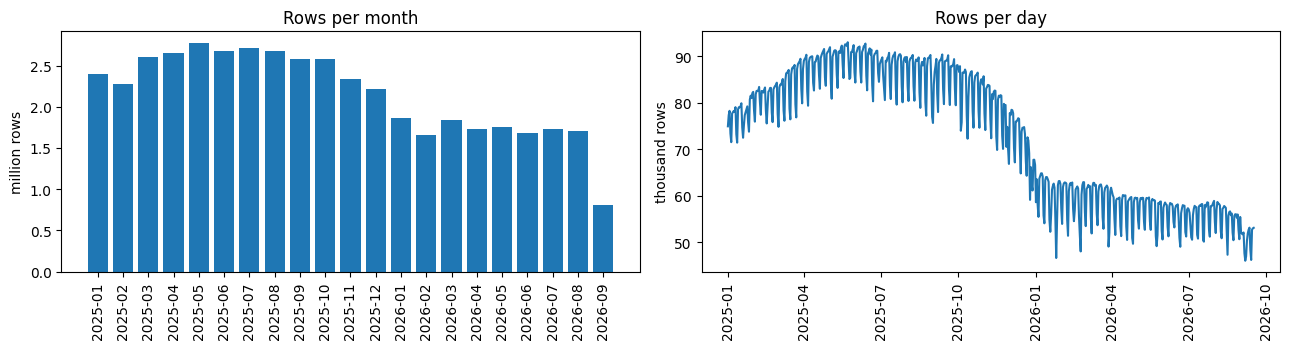

In [16]:
fig, (ax_month, ax_day) = plt.subplots(1, 2, figsize=(13, 3.6))
ax_month.bar(per_month["month"], per_month["rows"] / 1e6)
ax_month.set(title="Rows per month", ylabel="million rows")
ax_day.plot(plan_df["day"], plan_df["rows"] / 1e3)
ax_day.set(title="Rows per day", ylabel="thousand rows")
ax_day.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax_day.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
for ax in (ax_month, ax_day):
    ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

#### 6. Proses Pengambilan Data (*Gathering*)

Setiap hari diambil lewat endpoint CSV dengan skema tetap, divalidasi terhadap jumlah baris server (diulang hingga tiga kali bila berbeda), lalu disimpan sebagai Parquet.

`csv_to_table` mengubah isi CSV menjadi tabel Arrow bertipe sesuai `SCHEMA`.

In [17]:
def csv_to_table(content):
    options = pacsv.ConvertOptions(column_types=SCHEMA, include_columns=COLUMNS, strings_can_be_null=True)
    return pacsv.read_csv(io.BytesIO(content), convert_options=options).select(COLUMNS)

`fetch_rows` mengambil semua baris yang cocok dengan filter, per halaman, dengan urutan `:id` yang deterministik.

In [18]:
def day_file(day):
    return DAILY_DIR / day[:7] / f"{day}.parquet"


def fetch_rows(where, page_size=500_000):
    pages, offset = [], 0
    while True:
        params = {"$where": where, "$order": ":id", "$limit": page_size, "$offset": offset}
        table = csv_to_table(soda_get(RESOURCE + ".csv", params).content)
        pages.append(table)
        if table.num_rows < page_size:
            return pa.concat_tables(pages)
        offset += page_size

`download_day` mengunduh satu hari, memvalidasi jumlah barisnya, dan menyimpannya lewat berkas sementara agar file yang tampak selalu utuh. Fungsi mengembalikan lama unduhan (0 bila dilewati).

In [19]:
def download_day(day, server_rows):
    dest = day_file(day)
    if dest.exists() and pq.ParquetFile(dest).metadata.num_rows == server_rows:
        return 0.0  # already downloaded and complete
    start = dt.date.fromisoformat(day)
    where = (
        f"transit_timestamp >= '{start}T00:00:00' AND transit_timestamp < '{start + dt.timedelta(days=1)}T00:00:00' "
        f"AND transit_timestamp <= '{CUTOFF_TS}'"
    )
    t0 = time.time()
    for _ in range(3):
        table = fetch_rows(where)
        if table.num_rows == server_rows:
            break
        time.sleep(5)
    else:
        raise RuntimeError(f"{day}: got {table.num_rows} rows, server has {server_rows}")
    dest.parent.mkdir(parents=True, exist_ok=True)
    tmp = dest.with_suffix(".tmp")
    pq.write_table(table, tmp, compression="zstd")
    tmp.replace(dest)
    return time.time() - t0

##### 6.1 Uji pada satu hari

Fungsi diuji pada hari pertama; hasilnya dibaca kembali dari Parquet.

In [20]:
test_day = min(plan)
download_day(test_day, plan[test_day])

test_df = pq.read_table(day_file(test_day)).to_pandas()
print(f"{test_day}: {fmt(len(test_df))} rows x {test_df.shape[1]} columns (server: {fmt(plan[test_day])})")
test_df.head()

2025-01-01: 74.914 rows x 12 columns (server: 74.914)


,transit_timestamp,transit_mode,station_complex_id,station_complex,borough,payment_method,fare_class_category,ridership,transfers,latitude,longitude,georeference
0,2025-01-01,subway,107,"Broad St (J,Z)",Manhattan,metrocard,Metrocard - Seniors & Disability,2.0,0.0,40.706474,-74.011055,POINT (-74.011055 40.706474)
1,2025-01-01,subway,122,Graham Av (L),Brooklyn,metrocard,Metrocard - Full Fare,8.0,0.0,40.714565,-73.944050,POINT (-73.94405 40.714565)
2,2025-01-01,subway,135,Livonia Av (L),Brooklyn,metrocard,Metrocard - Seniors & Disability,1.0,1.0,40.664040,-73.900570,POINT (-73.90057 40.66404)
3,2025-01-01,subway,169,"Canal St (A,C,E)",Manhattan,omny,OMNY - Full Fare,171.0,0.0,40.720825,-74.005226,POINT (-74.005226 40.720825)
4,2025-01-01,subway,173,"High St (A,C)",Brooklyn,metrocard,Metrocard - Full Fare,59.0,1.0,40.699337,-73.990530,POINT (-73.99053 40.699337)


##### 6.2 Pengambilan seluruh hari

Seluruh hari diunduh paralel dengan `WORKERS` *thread*.

In [21]:
seconds = {}
t0 = time.time()
with ThreadPoolExecutor(WORKERS) as pool:
    futures = {pool.submit(download_day, d, n): d for d, n in plan.items()}
    for f in tqdm(as_completed(futures), total=len(futures), desc="Downloading days", unit="day"):
        seconds[futures[f]] = f.result()
print(f"Finished in {fmt((time.time() - t0) / 60, 1)} minutes")

Finished in 11,3 minutes


Ringkasan pengambilan. Jumlah baris dihitung dari metadata file harian; hari yang sudah ada dilewati dan tidak dihitung dalam waktu rata-rata.

In [22]:
n_daily = sum(pq.ParquetFile(day_file(d)).metadata.num_rows for d in plan)
downloaded = [s for s in seconds.values() if s > 0]

show_table(pd.DataFrame([
    ("Days collected", fmt(len(seconds))),
    ("Downloaded in this run", fmt(len(downloaded))),
    ("Skipped (already present)", fmt(len(seconds) - len(downloaded))),
    ("Rows in daily files", fmt(n_daily)),
    ("Rows on server", fmt(PLAN_ROWS)),
    ("Mean time per downloaded day (s)", fmt(sum(downloaded) / len(downloaded), 1) if downloaded else "-"),
    ("Total size of daily files (MB)", fmt(sum(day_file(d).stat().st_size for d in plan) / 1e6, 1)),
], columns=["Summary", "Value"]))

Summary,Value
Days collected,624
Downloaded in this run,623
Skipped (already present),1
Rows in daily files,45.244.036
Rows on server,45.244.036
Mean time per downloaded day (s),"6,4"
Total size of daily files (MB),"374,3"


#### 7. Penggabungan Data

Seluruh potongan berasal dari satu dataset dan berkolom sama, sehingga penggabungannya berupa *concat* vertikal (setara `UNION ALL`); *join* tidak diperlukan. Penggabungan dilakukan berjenjang: contoh dengan `pandas`, lalu harian -> bulanan -> satu file dengan DuckDB, yang membaca Parquet secara kolumnar.

##### 7.1 Contoh *concat*

Tiga hari pertama digabung dengan `pd.concat`.

In [23]:
chunks = [pq.read_table(day_file(d)).to_pandas() for d in sorted(plan)[:3]]
combined = pd.concat(chunks, ignore_index=True)

assert len(combined) == sum(map(len, chunks))
print(" + ".join(fmt(len(c)) for c in chunks), "=", fmt(len(combined)), "rows")

74.914 + 77.324 + 78.251 = 230.489 rows


##### 7.2 Harian ke bulanan

File harian tiap bulan dibaca dengan pola `*.parquet`, diurutkan menurut `SORT_KEYS`, dan ditulis sebagai satu file Parquet. Koneksi DuckDB dibuat lebih dulu.

In [24]:
con = duckdb.connect()
con.execute("SET enable_progress_bar=false; SET memory_limit='6GB'; SET threads=4")

ORDER_BY = ", ".join(SORT_KEYS)
COPY_OPTS = "FORMAT parquet, COMPRESSION zstd, ROW_GROUP_SIZE 245760"

`merge_month` menggabungkan satu bulan dan mencatat rentang waktunya.

In [25]:
def month_file(month):
    year, mon = month.split("-")
    return MONTHLY_DIR / f"year={year}" / f"month={mon}" / "part-0.parquet"


def merge_month(month, server_rows):
    dest = month_file(month)
    if not (dest.exists() and pq.ParquetFile(dest).metadata.num_rows == server_rows):
        dest.parent.mkdir(parents=True, exist_ok=True)
        tmp = dest.with_suffix(".tmp")
        con.execute(f"COPY (SELECT * FROM read_parquet('{DAILY_DIR / month}/*.parquet') ORDER BY {ORDER_BY}) TO '{tmp}' ({COPY_OPTS})")
        tmp.replace(dest)
    first_ts, last_ts = con.execute(f"SELECT min(transit_timestamp), max(transit_timestamp) FROM read_parquet('{dest}')").fetchone()
    return {
        "month": month,
        "days": len(list((DAILY_DIR / month).glob("*.parquet"))),
        "rows": pq.ParquetFile(dest).metadata.num_rows,
        "server_rows": server_rows,
        "MB": round(dest.stat().st_size / 1e6, 1),
        "first_ts": first_ts,
        "last_ts": last_ts,
    }

Ringkasan penggabungan per bulan; `rows` harus sama dengan `server_rows`.

In [26]:
manifest = pd.DataFrame([merge_month(m, n) for m, n in tqdm(zip(per_month["month"], per_month["rows"]), total=len(per_month), desc="Merging months", unit="month")])

show_table(manifest.assign(first_ts=manifest["first_ts"].dt.strftime("%Y-%m-%d %H:%M"), last_ts=manifest["last_ts"].dt.strftime("%Y-%m-%d %H:%M")), 1)

Merging months: 100%|██████████████| 21/21 [02:14<00:00,  6.39s/month]


month,days,rows,server_rows,MB,first_ts,last_ts
2025-01,31,2.398.982,2.398.982,"6,2",2025-01-01 00:00,2025-01-31 23:00
2025-02,28,2.273.357,2.273.357,"5,7",2025-02-01 00:00,2025-02-28 23:00
2025-03,31,2.599.249,2.599.249,"6,7",2025-03-01 00:00,2025-03-31 23:00
2025-04,30,2.646.409,2.646.409,"6,5",2025-04-01 00:00,2025-04-30 23:00
2025-05,31,2.776.119,2.776.119,"6,8",2025-05-01 00:00,2025-05-31 23:00
2025-06,30,2.673.221,2.673.221,"6,7",2025-06-01 00:00,2025-06-30 23:00
2025-07,31,2.711.975,2.711.975,"6,8",2025-07-01 00:00,2025-07-31 23:00
2025-08,31,2.681.448,2.681.448,"6,8",2025-08-01 00:00,2025-08-31 23:00
2025-09,30,2.581.490,2.581.490,"6,6",2025-09-01 00:00,2025-09-30 23:00
2025-10,31,2.578.816,2.578.816,"6,7",2025-10-01 00:00,2025-10-31 23:00


Pemeriksaan: jumlah baris tiap bulan sama dengan server, dan rentang waktu antarbulan tidak tumpang tindih, sehingga penyambungan berurutan tetap terurut menurut waktu.

In [27]:
assert (manifest["rows"] == manifest["server_rows"]).all(), "A month has a row count that differs from the server."
assert (manifest["first_ts"].iloc[1:].values > manifest["last_ts"].iloc[:-1].values).all(), "Monthly time ranges overlap."
print(f"{len(manifest)} monthly files, {fmt(manifest['rows'].sum())} rows: match the server and do not overlap.")

21 monthly files, 45.244.036 rows: match the server and do not overlap.


##### 7.3 Bulanan ke satu file final

File bulanan disambung berurutan menjadi satu file. `hive_partitioning=false` mencegah DuckDB menambahkan kolom `year` dan `month` dari nama folder.

In [28]:
FINAL_PATH = FINAL_DIR / f"mta_subway_hourly_ridership_{min(plan)[:7]}_{max(plan)[:7]}.parquet"
file_list = ", ".join(f"'{month_file(m)}'" for m in per_month["month"])

con.execute(f"COPY (SELECT * FROM read_parquet([{file_list}], hive_partitioning=false)) TO '{FINAL_PATH}' ({COPY_OPTS})")
print(f"Final file : {FINAL_PATH.name}")
print(f"Size       : {fmt(FINAL_PATH.stat().st_size / 1e6, 1)} MB")

Final file : mta_subway_hourly_ridership_2025-01_2026-09.parquet
Size       : 124,2 MB


#### 8. Pemeriksaan Struktur Awal Dataset

Dataset final dibuka sebagai *view* DuckDB (`mta`) sehingga dapat dikueri dengan SQL tanpa memuat seluruh baris ke memori.

##### 8.1 Dimensi dan tipe data

Jumlah baris, jumlah kolom, dan tipe data tiap kolom:

In [29]:
con.execute(f"CREATE OR REPLACE VIEW mta AS SELECT * FROM read_parquet('{FINAL_PATH}')")

n_rows = con.sql("SELECT count(*) FROM mta").fetchone()[0]
print(f"Shape: {fmt(n_rows)} rows x {len(COLUMNS)} columns")
show_table(con.sql("DESCRIBE mta").df()[["column_name", "column_type"]].set_axis(["column", "type"], axis=1))

Shape: 45.244.036 rows x 12 columns


column,type
transit_timestamp,TIMESTAMP
transit_mode,VARCHAR
station_complex_id,VARCHAR
station_complex,VARCHAR
borough,VARCHAR
payment_method,VARCHAR
fare_class_category,VARCHAR
ridership,DOUBLE
transfers,DOUBLE
latitude,DOUBLE


##### 8.2 Contoh baris dan `info`

Lima baris pertama:

In [30]:
con.sql("SELECT * FROM mta LIMIT 5").df()

,transit_timestamp,transit_mode,station_complex_id,station_complex,borough,payment_method,fare_class_category,ridership,transfers,latitude,longitude,georeference
0,2025-01-01,subway,1,"Astoria-Ditmars Blvd (N,W)",Queens,metrocard,Metrocard - Full Fare,7.0,0.0,40.775036,-73.91203,POINT (-73.91203 40.775036)
1,2025-01-01,subway,1,"Astoria-Ditmars Blvd (N,W)",Queens,metrocard,Metrocard - Other,1.0,0.0,40.775036,-73.91203,POINT (-73.91203 40.775036)
2,2025-01-01,subway,1,"Astoria-Ditmars Blvd (N,W)",Queens,metrocard,Metrocard - Unlimited 30-Day,5.0,0.0,40.775036,-73.91203,POINT (-73.91203 40.775036)
3,2025-01-01,subway,1,"Astoria-Ditmars Blvd (N,W)",Queens,metrocard,Metrocard - Unlimited 7-Day,5.0,0.0,40.775036,-73.91203,POINT (-73.91203 40.775036)
4,2025-01-01,subway,1,"Astoria-Ditmars Blvd (N,W)",Queens,omny,OMNY - Full Fare,76.0,0.0,40.775036,-73.91203,POINT (-73.91203 40.775036)


`info()` pada sampel acak 100.000 baris (bukan seluruh data):

In [31]:
con.sql("SELECT * FROM mta USING SAMPLE 100000 ROWS (reservoir, 42)").df().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   transit_timestamp    100000 non-null  datetime64[us]
 1   transit_mode         100000 non-null  object        
 2   station_complex_id   100000 non-null  object        
 3   station_complex      100000 non-null  object        
 4   borough              100000 non-null  object        
 5   payment_method       100000 non-null  object        
 6   fare_class_category  100000 non-null  object        
 7   ridership            100000 non-null  float64       
 8   transfers            100000 non-null  float64       
 9   latitude             100000 non-null  float64       
 10  longitude            100000 non-null  float64       
 11  georeference         100000 non-null  object        
dtypes: datetime64[us](1), float64(4), object(7)
memory usage: 9.2+ MB


##### 8.3 Nilai kosong

Jumlah `NULL` pada semua kolom dan string kosong pada kolom teks.

In [32]:
TEXT_COLS = [f.name for f in SCHEMA if pa.types.is_string(f.type)]
q_null = ", ".join(f"count(*) - count({c}) AS {c}" for c in COLUMNS)
q_empty = ", ".join(f"count(*) FILTER (WHERE trim({c}) = '') AS {c}" for c in TEXT_COLS)

nulls = con.sql(f"SELECT {q_null} FROM mta").df().iloc[0]
empty = con.sql(f"SELECT {q_empty} FROM mta").df().iloc[0]
show_table(pd.DataFrame({"column": COLUMNS, "null_count": nulls.values, "empty_string_count": [empty.get(c, 0) for c in COLUMNS]}))

column,null_count,empty_string_count
transit_timestamp,0,0
transit_mode,0,0
station_complex_id,0,0
station_complex,0,0
borough,0,0
payment_method,0,0
fare_class_category,0,0
ridership,0,0
transfers,0,0
latitude,0,0


##### 8.4 Kolom kategorik

Jumlah nilai unik tiap kolom teks:

In [33]:
unique = con.sql("SELECT " + ", ".join(f"count(DISTINCT {c}) AS {c}" for c in TEXT_COLS) + " FROM mta").df().T
show_table(unique.reset_index().set_axis(["column", "unique_values"], axis=1))

column,unique_values
transit_mode,3
station_complex_id,428
station_complex,428
borough,5
payment_method,2
fare_class_category,12
georeference,428


Sebaran baris dan total penumpang untuk kolom kategori utama:

In [34]:
for col in ["transit_mode", "borough", "payment_method", "fare_class_category"]:
    dist = con.sql(f"""
        SELECT {col} AS value, count(*) AS row_count, round(100.0 * count(*) / {n_rows}, 2) AS pct, CAST(sum(ridership) AS BIGINT) AS ridership
        FROM mta GROUP BY 1 ORDER BY 2 DESC""").df()
    print(f"\nDistribution of {col}")
    display(show_table(dist, 2))


Distribution of transit_mode


value,row_count,pct,ridership
subway,44.911.671,"99,27",2.230.119.611
staten_island_railway,175.574,"0,39",3.743.955
tram,156.791,"0,35",5.125.946



Distribution of borough


value,row_count,pct,ridership
Brooklyn,15.989.346,"35,34",499.714.863
Manhattan,13.982.457,"30,90",1.251.922.578
Queens,7.858.047,"17,37",330.122.017
Bronx,7.238.610,"16,00",153.486.097
Staten Island,175.576,"0,39",3.743.957



Distribution of payment_method


value,row_count,pct,ridership
omny,25.071.062,"55,41",1.963.089.834
metrocard,20.172.974,"44,59",275.899.678



Distribution of fare_class_category


value,row_count,pct,ridership
OMNY - Full Fare,6.213.926,"13,73",1.636.240.001
OMNY - Students,5.292.374,"11,70",134.801.750
OMNY - Seniors & Disability,5.101.297,"11,28",100.401.448
Metrocard - Other,4.970.766,"10,99",46.119.774
OMNY - Fair Fare,4.592.853,"10,15",61.408.422
OMNY - Other,3.870.612,"8,55",30.238.213
Metrocard - Unlimited 30-Day,3.807.705,"8,42",62.181.280
Metrocard - Unlimited 7-Day,3.326.928,"7,35",56.041.345
Metrocard - Full Fare,3.317.743,"7,33",73.350.998
Metrocard - Fair Fare,2.448.705,"5,41",23.062.550


##### 8.5 Kolom numerik

Ringkasan statistik `ridership` dan `transfers`.

In [35]:
def summarize(col):
    return (f"SELECT '{col}' AS variable, min({col}) AS min, quantile_cont({col}, 0.5) AS median, avg({col}) AS mean, "
            f"quantile_cont({col}, 0.95) AS p95, max({col}) AS max, stddev({col}) AS std, sum({col}) AS total FROM mta")


show_table(con.sql(" UNION ALL ".join(map(summarize, ["ridership", "transfers"]))).df(), 2)

variable,min,median,mean,p95,max,std,total
ridership,"1,00","7,00","49,49","188,00","23.510,00","241,86","2.238.989.512,00"
transfers,"-30,00","0,00","2,47","9,00","2.556,00","17,74","111.767.871,00"


##### 8.6 Cakupan waktu

Rentang waktu serta jumlah jam dan hari unik:

In [36]:
time_span = con.sql("""
    SELECT strftime(min(transit_timestamp), '%Y-%m-%d %H:%M') AS first_ts, strftime(max(transit_timestamp), '%Y-%m-%d %H:%M') AS last_ts,
           count(DISTINCT transit_timestamp) AS unique_hours, count(DISTINCT CAST(transit_timestamp AS DATE)) AS unique_days
    FROM mta""").df()
show_table(time_span)

first_ts,last_ts,unique_hours,unique_days
2025-01-01 00:00,2026-09-16 23:00,14.975,624


Jam yang tidak muncul pada rentang tersebut:

In [37]:
missing_hours = con.sql("""
    SELECT h AS missing_hour
    FROM generate_series((SELECT min(transit_timestamp) FROM mta), (SELECT max(transit_timestamp) FROM mta), INTERVAL 1 HOUR) AS g(h)
    WHERE h NOT IN (SELECT DISTINCT transit_timestamp FROM mta)""").df()
print(f"Missing hours: {len(missing_hours)}")
missing_hours

Missing hours: 1


,missing_hour
0,2026-03-08 02:00:00


##### 8.7 Catatan awal untuk tahap berikutnya

Pemeriksaan cepat yang hanya **mencatat** temuan; tidak ada perbaikan pada tahap ini.

In [38]:
show_table(con.sql("""
    SELECT count(*) FILTER (WHERE transfers < 0) AS negative_transfers,
           count(*) FILTER (WHERE transfers > ridership) AS transfers_exceeding_ridership,
           count(*) FILTER (WHERE ridership <= 0) AS nonpositive_ridership
    FROM mta""").df().T.reset_index().set_axis(["check", "row_count"], axis=1))

check,row_count
negative_transfers,226
transfers_exceeding_ridership,0
nonpositive_ridership,0


Kompleks stasiun yang tercatat dengan lebih dari satu moda:

In [39]:
con.sql("""
    SELECT station_complex_id, station_complex, string_agg(DISTINCT transit_mode, ', ') AS modes
    FROM mta GROUP BY 1, 2 HAVING count(DISTINCT transit_mode) > 1""").df()

,station_complex_id,station_complex,modes
0,501,St George (SIR),"subway, staten_island_railway"


#### 9. Validasi Hasil *Gathering*

Bagian ini membuktikan bahwa dataset final lengkap dan sama dengan sumbernya.

##### 9.1 Perbandingan per hari dengan server

Server menghitung agregat harian dari data aslinya (jumlah baris, total `ridership`, total `transfers`). Hasilnya digabung (`pd.merge`) dengan agregat yang dihitung dari dataset final, berdasarkan tanggal.

In [40]:
server = pd.DataFrame(aggregate(
    "date_trunc_ymd(transit_timestamp) AS ymd, count(*) AS n, sum(ridership) AS r, sum(transfers) AS t",
    where=f"transit_timestamp <= '{CUTOFF_TS}'", group="ymd"))
server["ymd"] = server["ymd"].str[:10]
server = server[server["ymd"].isin(plan)].astype({"n": int, "r": float, "t": float})

attempt 1 failed (ReadTimeout); retrying in 1s


Agregat yang sama dihitung dari dataset final:

In [41]:
local = con.sql("""
    SELECT strftime(CAST(transit_timestamp AS DATE), '%Y-%m-%d') AS ymd, count(*) AS n, sum(ridership) AS r, sum(transfers) AS t
    FROM mta GROUP BY 1""").df()

Kedua agregat dibandingkan per hari dengan `pd.merge`:

In [42]:
compare = server.merge(local, on="ymd", how="outer", suffixes=("_server", "_final"), indicator=True)
mismatch = compare[["n_server", "r_server", "t_server"]].values != compare[["n_final", "r_final", "t_final"]].values
n_diff = int(((compare["_merge"] != "both") | mismatch.any(axis=1)).sum())

print(f"Days compared: {len(compare)} | days that differ: {n_diff}")
show_table(compare.head(5).drop(columns="_merge"))

Days compared: 624 | days that differ: 0


ymd,n_server,r_server,t_server,n_final,r_final,t_final
2025-01-01,74.914,1.813.725,54.931,74.914,1.813.725,54.931
2025-01-02,77.324,3.433.271,160.717,77.324,3.433.271,160.717
2025-01-03,78.251,3.467.018,161.389,78.251,3.467.018,161.389
2025-01-04,73.385,2.344.771,86.910,73.385,2.344.771,86.910
2025-01-05,71.505,1.818.179,65.133,71.505,1.818.179,65.133


##### 9.2 Keunikan dan urutan baris

Data sudah terurut menurut `SORT_KEYS`, sehingga duplikat pasti berdampingan. Membandingkan tiap baris dengan baris sebelumnya (`lag`) cukup untuk memeriksa duplikat dan urutan, dan lebih hemat memori daripada mengelompokkan 45 juta kunci. Pemeriksaan dilakukan pada tiap file bulanan (kunci lengkap) dan pada file final (`transit_timestamp` tidak boleh mundur).

In [43]:
def check_order(path):
    keys = ", ".join(SORT_KEYS)
    dupes, unsorted = con.execute(f"""
        WITH t AS (
            SELECT ({keys}) AS k, lag(({keys})) OVER (ORDER BY file_row_number) AS prev
            FROM read_parquet('{path}', file_row_number = true))
        SELECT count(*) FILTER (WHERE k = prev), count(*) FILTER (WHERE k < prev) FROM t""").fetchone()
    return {"dupes": dupes, "unsorted": unsorted}

Pemeriksaan pada tiap file bulanan:

In [44]:
order_check = pd.DataFrame([{"month": m, **check_order(month_file(m))} for m in tqdm(per_month["month"], desc="Checking order and duplicates", unit="month")])
print(f"Duplicate keys (all monthly files): {order_check['dupes'].sum()}")
print(f"Unsorted rows (monthly files)     : {order_check['unsorted'].sum()}")

Checking order and duplicates: 100%|█| 21/21 [00:35<00:00,  1.67s/mont
Duplicate keys (all monthly files): 0
Unsorted rows (monthly files)     : 0


Pemeriksaan pada file final:

In [45]:
final_backward = con.execute(f"""
    WITH t AS (
        SELECT transit_timestamp AS ts, lag(transit_timestamp) OVER (ORDER BY file_row_number) AS prev
        FROM read_parquet('{FINAL_PATH}', file_row_number = true))
    SELECT count(*) FILTER (WHERE ts < prev) FROM t""").fetchone()[0]
print(f"Timestamps going backward (final) : {final_backward}")

Timestamps going backward (final) : 0


#### 10. Dataset Akhir Hasil *Gathering*

Ringkasan dataset akhir yang diserahkan ke tahap *assessing* dan *cleaning*.

In [46]:
show_table(pd.DataFrame([
    ("File name", FINAL_PATH.name),
    ("Folder", str(FINAL_DIR)),
    ("Format", "Apache Parquet (zstd compression)"),
    ("File size", f"{fmt(FINAL_PATH.stat().st_size / 1e6, 1)} MB"),
    ("Rows", fmt(n_rows)),
    ("Columns", len(COLUMNS)),
    ("Time range", f"{time_span.loc[0, 'first_ts']} to {time_span.loc[0, 'last_ts']}"),
    ("Station complexes", fmt(con.sql("SELECT count(DISTINCT station_complex_id) FROM mta").fetchone()[0])),
    ("Total ridership", fmt(con.sql("SELECT sum(ridership) FROM mta").fetchone()[0])),
    ("Snapshot cutoff", CUTOFF_TS[:16].replace("T", " ")),
], columns=["Attribute", "Value"]))

Attribute,Value
File name,mta_subway_hourly_ridership_2025-01_2026-09.parquet
Folder,/content/mta_subway/03_final
Format,Apache Parquet (zstd compression)
File size,"124,2 MB"
Rows,45.244.036
Columns,12
Time range,2025-01-01 00:00 to 2026-09-16 23:00
Station complexes,428
Total ridership,2.238.989.512
Snapshot cutoff,2026-09-16 23:00


Folder `/content` dihapus saat sesi berakhir. Centang `SAVE_TO_DRIVE` untuk menyalin dataset final ke Google Drive (Colab akan meminta izin akses).

In [47]:
SAVE_TO_DRIVE = True  #@param {type:"boolean"}

if SAVE_TO_DRIVE:
    import shutil
    from google.colab import drive

    drive.mount("/content/drive")
    shutil.copy2(FINAL_PATH, "/content/drive/MyDrive/")

Mounted at /content/drive


##### Ringkasan

- Data dikumpulkan dari satu sumber (SODA API `5wq4-mkjj`) dengan batas *snapshot* 2026-09-16 23:00, sesuai kondisi server setelah pembaruan 30 September 2026.
- MTA merevisi baris beberapa bulan terakhir pada setiap pembaruan mingguan, sehingga salinan yang tetap adalah file final di Google Drive.
- 624 potongan harian digabung menjadi 21 file bulanan lalu satu file final: **45.244.036 baris × 12 kolom**.
- Catatan awal: 226 baris `transfers` negatif, satu jam tidak muncul (2026-03-08 02:00, peralihan DST; lihat bagian IV), dan satu stasiun (St George, ID 501) tercatat dengan dua moda.

### IV. Data Wrangling – *Assessing* dan *Cleaning Data*

Tahap ini menilai kualitas dataset hasil *gathering* dengan aturan yang terukur, menandai setiap baris yang melanggar (*error tagging*), membersihkannya, lalu membuktikan hasilnya dengan metrik kualitas sebelum dan sesudah *cleaning*. Seluruh proses memakai *view* DuckDB `mta` dari bagian III, sehingga 45 juta baris tidak perlu dimuat ke memori.

#### 1. Aturan Kualitas Data

`transit_timestamp` adalah waktu lokal New York tanpa zona waktu, sehingga jam peralihan DST (*daylight saving time*) perlu diperiksa. Jam tersebut dihitung dari basis data zona waktu `zoneinfo`: jam yang tidak ada karena jam dimajukan (Maret) dan jam yang terjadi dua kali karena jam dimundurkan (November).

In [48]:
from zoneinfo import ZoneInfo

NY_TZ = ZoneInfo("America/New_York")


def dst_transition_hours(first, last):
    """Local New York hours that do not exist (spring forward) or occur twice (fall back)."""
    found, hour = {}, first
    while hour <= last:
        if hour.replace(tzinfo=NY_TZ, fold=0).utcoffset() != hour.replace(tzinfo=NY_TZ, fold=1).utcoffset():
            round_trip = hour.replace(tzinfo=NY_TZ).astimezone(dt.timezone.utc).astimezone(NY_TZ).replace(tzinfo=None)
            found[hour] = "repeated" if round_trip == hour else "nonexistent"
        hour += dt.timedelta(hours=1)
    return found


DST_HOURS = dst_transition_hours(*con.sql("SELECT min(transit_timestamp), max(transit_timestamp) FROM mta").fetchone())
show_table(pd.DataFrame({"local_hour": [h.strftime("%Y-%m-%d %H:%M") for h in DST_HOURS], "type": list(DST_HOURS.values())}))

local_hour,type
2025-03-09 02:00,nonexistent
2025-11-02 01:00,repeated
2026-03-08 02:00,nonexistent


Moda dominan (nilai terbanyak) setiap kompleks stasiun menjadi acuan konsistensi `transit_mode`.

In [49]:
con.execute("CREATE OR REPLACE TABLE station_mode AS SELECT station_complex_id, mode(transit_mode) AS station_mode FROM mta GROUP BY 1")
print(f"Dominant mode computed for {con.sql('SELECT count(*) FROM station_mode').fetchone()[0]} station complexes")

Dominant mode computed for 428 station complexes


Daftar aturan menurut dimensi kualitas data. Tingkat `error` berarti nilainya salah dan harus diperbaiki; `warning` berarti nilainya bukan salah catat tetapi perlu ditandai. Keunikan baris sudah diperiksa pada bagian III.9.2 dan dipakai kembali pada metrik kualitas.

In [50]:
RULES = pd.DataFrame([
    ("missing_value", "Completeness", "error", "A column is NULL"),
    ("invalid_category", "Validity", "error", "transit_mode, payment_method, or borough outside its documented values"),
    ("nonpositive_ridership", "Validity", "error", "ridership is zero or negative"),
    ("negative_transfers", "Validity", "error", "transfers is negative"),
    ("transfers_exceed_ridership", "Validity", "error", "transfers is greater than ridership"),
    ("non_integer_count", "Validity", "error", "ridership or transfers is not a whole number"),
    ("outside_nyc", "Validity", "error", "Coordinates outside the New York City extent"),
    ("not_on_hour", "Validity", "error", "transit_timestamp is not on the hour"),
    ("fare_class_payment_mismatch", "Consistency", "error", "fare_class_category prefix differs from payment_method"),
    ("station_mode_mismatch", "Consistency", "error", "transit_mode differs from the station's dominant mode"),
    ("georeference_mismatch", "Consistency", "error", "georeference differs from latitude and longitude"),
    ("dst_transition_hour", "Accuracy", "warning", "Local hour that does not exist or occurs twice (DST)"),
], columns=["tag", "dimension", "severity", "rule"])
show_table(RULES)

tag,dimension,severity,rule
missing_value,Completeness,error,A column is NULL
invalid_category,Validity,error,"transit_mode, payment_method, or borough outside its documented values"
nonpositive_ridership,Validity,error,ridership is zero or negative
negative_transfers,Validity,error,transfers is negative
transfers_exceed_ridership,Validity,error,transfers is greater than ridership
non_integer_count,Validity,error,ridership or transfers is not a whole number
outside_nyc,Validity,error,Coordinates outside the New York City extent
not_on_hour,Validity,error,transit_timestamp is not on the hour
fare_class_payment_mismatch,Consistency,error,fare_class_category prefix differs from payment_method
station_mode_mismatch,Consistency,error,transit_mode differs from the station's dominant mode


Setiap aturan diterjemahkan menjadi kondisi SQL yang bernilai benar bila sebuah baris **melanggar** aturan tersebut. Batas koordinat adalah perkiraan wilayah New York City.

In [51]:
NYC_LAT, NYC_LON = (40.47, 40.92), (-74.26, -73.70)
DST_SQL = ", ".join(f"TIMESTAMP '{h}'" for h in DST_HOURS)
POINT = "string_split(trim(georeference, 'POINT ()'), ' ')"  # [longitude, latitude] as text

VIOLATION_SQL = {
    "missing_value": " OR ".join(f"{c} IS NULL" for c in COLUMNS),
    "invalid_category": "transit_mode NOT IN ('subway', 'staten_island_railway', 'tram') OR payment_method NOT IN ('omny', 'metrocard') "
                        "OR borough NOT IN ('Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island')",
    "nonpositive_ridership": "ridership <= 0",
    "negative_transfers": "transfers < 0",
    "transfers_exceed_ridership": "transfers > ridership",
    "non_integer_count": "ridership <> floor(ridership) OR transfers <> floor(transfers)",
    "outside_nyc": f"latitude NOT BETWEEN {NYC_LAT[0]} AND {NYC_LAT[1]} OR longitude NOT BETWEEN {NYC_LON[0]} AND {NYC_LON[1]}",
    "not_on_hour": "date_trunc('hour', transit_timestamp) <> transit_timestamp",
    "fare_class_payment_mismatch": "lower(split_part(fare_class_category, ' - ', 1)) <> payment_method",
    "station_mode_mismatch": "transit_mode <> station_mode",
    "georeference_mismatch": f"CAST({POINT}[1] AS DOUBLE) <> longitude OR CAST({POINT}[2] AS DOUBLE) <> latitude",
    "dst_transition_hour": f"transit_timestamp IN ({DST_SQL})",
}
assert list(VIOLATION_SQL) == RULES["tag"].tolist(), "Every rule needs exactly one SQL condition."

#### 2. Penandaan Kesalahan (*Error Tagging*)

`tag_sql` memeriksa seluruh aturan dalam satu pemindaian dan memberi setiap baris daftar tag pelanggaran (`error_tags`). Baris yang memiliki tag disimpan ke tabel `flagged`, sehingga analisis berikutnya tidak perlu memindai ulang 45 juta baris.

In [52]:
def tag_sql(source):
    """Rows of `source` with an error_tags list; list_distinct drops the NULLs of rules that pass."""
    tags = ", ".join(f"CASE WHEN {cond} THEN '{tag}' END" for tag, cond in VIOLATION_SQL.items())
    return f"SELECT t.*, list_sort(list_distinct([{tags}])) AS error_tags FROM {source} t JOIN station_mode USING (station_complex_id)"


def count_tags(table):
    return con.sql(f"SELECT tag, count(*) AS rows FROM (SELECT unnest(error_tags) AS tag FROM {table}) GROUP BY 1").df()


con.execute(f"CREATE OR REPLACE TABLE flagged AS SELECT * FROM ({tag_sql('mta')}) WHERE len(error_tags) > 0")
print(f"Rows with at least one tag: {fmt(con.sql('SELECT count(*) FROM flagged').fetchone()[0])} of {fmt(n_rows)}")

Rows with at least one tag: 3.672 of 45.244.036


Jumlah baris per tag:

In [53]:
diagnosis = RULES.merge(count_tags("flagged"), on="tag", how="left").fillna({"rows": 0}).astype({"rows": int})
show_table(diagnosis[["tag", "dimension", "severity", "rows"]])

tag,dimension,severity,rows
missing_value,Completeness,error,0
invalid_category,Validity,error,0
nonpositive_ridership,Validity,error,0
negative_transfers,Validity,error,226
transfers_exceed_ridership,Validity,error,0
non_integer_count,Validity,error,0
outside_nyc,Validity,error,0
not_on_hour,Validity,error,0
fare_class_payment_mismatch,Consistency,error,0
station_mode_mismatch,Consistency,error,2


Contoh baris bertanda, dua baris untuk setiap kombinasi tag:

In [54]:
show_table(con.sql("""
    SELECT array_to_string(error_tags, ', ') AS error_tags, strftime(transit_timestamp, '%Y-%m-%d %H:%M') AS hour,
           station_complex_id, station_complex, transit_mode, fare_class_category, ridership, transfers
    FROM flagged
    QUALIFY row_number() OVER (PARTITION BY error_tags ORDER BY transit_timestamp, station_complex_id) <= 2
    ORDER BY 1, 2""").df())

error_tags,hour,station_complex_id,station_complex,transit_mode,fare_class_category,ridership,transfers
dst_transition_hour,2025-03-09 02:00,1,"Astoria-Ditmars Blvd (N,W)",subway,Metrocard - Full Fare,5,0
dst_transition_hour,2025-03-09 02:00,1,"Astoria-Ditmars Blvd (N,W)",subway,Metrocard - Other,4,0
negative_transfers,2026-05-17 18:00,629,"Metropolitan Av/Lorimer St (G,L)",subway,OMNY - Fair Fare,23,-1
negative_transfers,2026-05-22 21:00,204,Beach 67 St (A),subway,OMNY - Full Fare,23,-2
station_mode_mismatch,2026-06-18 14:00,501,St George (SIR),subway,OMNY - Other,1,0
station_mode_mismatch,2026-09-08 13:00,501,St George (SIR),subway,OMNY - Other,1,0


#### 3. Diagnosis Temuan

##### 3.1 Moda kompleks stasiun

Sebaran `transit_mode` pada kompleks stasiun yang memiliki baris `station_mode_mismatch`:

In [55]:
show_table(con.sql("""
    SELECT station_complex_id, station_complex, transit_mode, count(*) AS rows,
           strftime(min(transit_timestamp), '%Y-%m-%d') AS first_day, strftime(max(transit_timestamp), '%Y-%m-%d') AS last_day
    FROM mta
    WHERE station_complex_id IN (SELECT station_complex_id FROM flagged WHERE list_contains(error_tags, 'station_mode_mismatch'))
    GROUP BY 1, 2, 3 ORDER BY 1, rows DESC""").df())

station_complex_id,station_complex,transit_mode,rows,first_day,last_day
501,St George (SIR),staten_island_railway,116.098,2025-01-01,2026-09-16
501,St George (SIR),subway,2,2026-06-18,2026-09-08


##### 3.2 `transfers` negatif

`transfers` adalah bagian dari `ridership` yang masuk lewat transfer gratis, sehingga nilainya tidak mungkin negatif. Sebaran baris bertanda menurut stasiun:

In [56]:
show_table(con.sql("""
    SELECT station_complex_id, station_complex, string_agg(DISTINCT payment_method, ', ') AS payment_method,
           count(*) AS rows, min(transfers) AS min_transfers, sum(transfers) AS sum_transfers,
           strftime(min(transit_timestamp), '%Y-%m-%d') AS first_day, strftime(max(transit_timestamp), '%Y-%m-%d') AS last_day
    FROM flagged WHERE list_contains(error_tags, 'negative_transfers')
    GROUP BY 1, 2 ORDER BY rows DESC""").df())

station_complex_id,station_complex,payment_method,rows,min_transfers,sum_transfers,first_day,last_day
204,Beach 67 St (A),omny,91,-2,-96,2026-05-22,2026-09-16
601,"14 St/6 Av (1,2,3,L,F,M)",omny,64,-30,-119,2026-05-25,2026-09-11
629,"Metropolitan Av/Lorimer St (G,L)",omny,42,-2,-43,2026-05-17,2026-09-15
83,"Woodhaven Blvd (J,Z)",omny,29,-2,-30,2026-05-25,2026-09-03


##### 3.3 Jam peralihan DST

Jumlah baris dan penumpang pada jam peralihan dibandingkan dengan rata-rata jam yang sama satu minggu sebelum dan sesudahnya:

In [57]:
def hour_totals(hour):
    return con.execute("SELECT count(*), coalesce(sum(ridership), 0) FROM mta WHERE transit_timestamp = ?", [hour]).fetchone()


dst_rows = []
for hour, kind in DST_HOURS.items():
    rows, riders = hour_totals(hour)
    week_avg = sum(hour_totals(hour + dt.timedelta(days=d))[1] for d in (-7, 7)) / 2
    dst_rows.append((hour.strftime("%Y-%m-%d %H:%M"), kind, rows, riders, week_avg))
show_table(pd.DataFrame(dst_rows, columns=["local_hour", "type", "rows", "ridership", "same_hour_avg_±7_days"]))

local_hour,type,rows,ridership,same_hour_avg_±7_days
2025-03-09 02:00,nonexistent,1.255,4.340,12.636
2025-11-02 01:00,repeated,2.189,47.605,27.060
2026-03-08 02:00,nonexistent,0,0,14.775


##### 3.4 Nilai ekstrem `ridership`

Lima kombinasi jam dan kompleks stasiun dengan penumpang terbanyak, untuk menilai apakah nilai ekstrem merupakan kesalahan:

In [58]:
show_table(con.sql("""
    SELECT strftime(transit_timestamp, '%Y-%m-%d %H:%M') AS hour, dayname(transit_timestamp) AS weekday, station_complex, sum(ridership) AS ridership
    FROM mta GROUP BY transit_timestamp, station_complex
    ORDER BY ridership DESC LIMIT 5""").df())

hour,weekday,station_complex,ridership
2026-07-15 17:00,Wednesday,"Grand Central-42 St (4,5,6,7,S)",25.147
2025-12-10 17:00,Wednesday,"Grand Central-42 St (4,5,6,7,S)",23.692
2026-06-23 17:00,Tuesday,"Grand Central-42 St (4,5,6,7,S)",23.426
2026-06-10 17:00,Wednesday,"Grand Central-42 St (4,5,6,7,S)",23.385
2026-07-28 17:00,Tuesday,"Grand Central-42 St (4,5,6,7,S)",23.211


#### 4. Metrik Kualitas Sebelum *Cleaning*

Skor setiap dimensi adalah persentase baris yang lolos seluruh aturan `error` pada dimensi tersebut. Keunikan memakai jumlah duplikat kunci dari bagian III.9.2. Aturan `warning` tidak mengurangi skor.

In [59]:
def quality_metrics(flagged_table, total_rows, duplicates):
    """Rows failing the error rules of each dimension, and the share of rows that pass."""
    errors = RULES[RULES["severity"] == "error"]
    groups = [*errors.groupby("dimension")["tag"], ("All row-level rules", errors["tag"])]
    failing = [(dim, con.sql(f"SELECT count(*) FROM {flagged_table} WHERE list_has_any(error_tags, {list(tags)})").fetchone()[0])
               for dim, tags in groups]
    metrics = pd.DataFrame([*failing[:-1], ("Uniqueness", duplicates), failing[-1]], columns=["dimension", "failing_rows"])
    metrics["score_pct"] = 100 * (1 - metrics["failing_rows"] / total_rows)
    return metrics

Metrik kualitas dataset hasil *gathering*:

In [60]:
metrics_before = quality_metrics("flagged", n_rows, int(order_check["dupes"].sum()))
show_table(metrics_before, 6)

dimension,failing_rows,score_pct
Completeness,0,"100,000000"
Consistency,2,"99,999996"
Validity,226,"99,999500"
Uniqueness,0,"100,000000"
All row-level rules,228,"99,999496"


#### 5. *Cleaning*

Tindakan untuk setiap temuan. Tidak ada baris yang dihapus, karena seluruh temuan dapat diperbaiki atau cukup ditandai.

| Temuan | Tindakan | Alasan |
|---|---|---|
| `station_mode_mismatch` | `transit_mode` diganti dengan moda dominan stasiunnya | Satu kompleks stasiun dilayani satu moda; nilai yang menyimpang adalah salah catat |
| `negative_transfers` | `transfers` negatif diubah menjadi 0 | `transfers` adalah jumlah orang sehingga tidak mungkin negatif; `ridership` pada baris yang sama tidak berubah |
| `ridership` dan `transfers` bertipe desimal | Diubah ke bilangan bulat (`INTEGER`) | Keduanya hitungan orang dan seluruh nilainya bulat (aturan `non_integer_count` lolos) |
| `dst_transition_hour` | Ditandai dengan kolom baru `is_dst_transition`; nilai tidak diubah | Penumpangnya nyata, tetapi label jamnya ambigu sehingga tidak dapat dipisah atau dipindah ke jam lain |
| Nilai ekstrem `ridership` | Dipertahankan | Seluruhnya terjadi di Grand Central-42 St pukul 17.00 pada hari kerja (jam sibuk sore), sehingga wajar dan bukan kesalahan |

`REPAIRS` memetakan kolom ke ekspresi perbaikannya; kolom lain disalin apa adanya. Perbaikan `transit_mode` hanya berlaku untuk stasiun yang barisnya bertanda `station_mode_mismatch`, dan kolom `is_dst_transition` ditambahkan di akhir. Kueri tidak memakai *join*, sehingga urutan baris file final tetap terjaga.

In [61]:
mode_fixes = con.sql("""
    SELECT DISTINCT station_complex_id, station_mode FROM flagged JOIN station_mode USING (station_complex_id)
    WHERE list_contains(error_tags, 'station_mode_mismatch')""").fetchall()
mode_case = " ".join(f"WHEN '{station}' THEN '{mode}'" for station, mode in mode_fixes)

REPAIRS = {
    "transit_mode": f"CASE station_complex_id {mode_case} ELSE transit_mode END" if mode_fixes else "transit_mode",
    "ridership": "CAST(ridership AS INTEGER)",
    "transfers": "CAST(greatest(transfers, 0) AS INTEGER)",
}
select_list = ", ".join(f"{REPAIRS.get(c, c)} AS {c}" for c in COLUMNS)
con.execute(f"CREATE OR REPLACE VIEW mta_clean AS SELECT {select_list}, transit_timestamp IN ({DST_SQL}) AS is_dst_transition FROM mta")
print(f"transit_mode repair: {REPAIRS['transit_mode']}")

transit_mode repair: CASE station_complex_id WHEN '501' THEN 'staten_island_railway' ELSE transit_mode END


Hasil *cleaning* ditulis sebagai file Parquet baru tanpa pengurutan ulang, karena urutan baris file final (terurut menurut `SORT_KEYS`) sudah terjaga:

In [62]:
CLEAN_DIR = BASE / "04_clean"
CLEAN_DIR.mkdir(exist_ok=True)
CLEAN_PATH = CLEAN_DIR / FINAL_PATH.name.replace("ridership_", "ridership_clean_")
CLEAN_SOURCE = f"read_parquet('{CLEAN_PATH}')"

con.execute(f"COPY (SELECT * FROM mta_clean) TO '{CLEAN_PATH}' ({COPY_OPTS})")
print(f"Clean file : {CLEAN_PATH.name}")
print(f"Size       : {fmt(CLEAN_PATH.stat().st_size / 1e6, 1)} MB")

Clean file : mta_subway_hourly_ridership_clean_2025-01_2026-09.parquet
Size       : 124,3 MB


#### 6. Validasi Hasil *Cleaning*

##### 6.1 Aturan kualitas pada data bersih

Seluruh aturan dijalankan ulang pada file bersih. Tag `error` harus nol, sedangkan tag `warning` tetap ada dan seluruh barisnya harus bernilai benar pada `is_dst_transition`. Sel berhenti dengan galat bila syarat ini tidak terpenuhi.

In [63]:
con.execute(f"CREATE OR REPLACE TABLE flagged_clean AS SELECT * FROM ({tag_sql(CLEAN_SOURCE)}) WHERE len(error_tags) > 0")
validation = diagnosis.merge(count_tags("flagged_clean"), on="tag", how="left", suffixes=("_before", "_after"))
validation = validation.fillna({"rows_after": 0}).astype({"rows_after": int})

errors_after = validation.loc[validation["severity"] == "error", "rows_after"].sum()
dst_unmarked = con.sql("SELECT count(*) FROM flagged_clean WHERE list_contains(error_tags, 'dst_transition_hour') AND NOT is_dst_transition").fetchone()[0]
assert errors_after == 0 and dst_unmarked == 0, "Cleaning left an error tag or an unmarked DST row."
show_table(validation[["tag", "severity", "rows_before", "rows_after"]])

tag,severity,rows_before,rows_after
missing_value,error,0,0
invalid_category,error,0,0
nonpositive_ridership,error,0,0
negative_transfers,error,226,0
transfers_exceed_ridership,error,0,0
non_integer_count,error,0,0
outside_nyc,error,0,0
not_on_hour,error,0,0
fare_class_payment_mismatch,error,0,0
station_mode_mismatch,error,2,0


##### 6.2 Metrik kualitas sebelum dan sesudah

*Cleaning* tidak menambah atau menghapus baris dan tidak mengubah kolom kunci, sehingga jumlah duplikat kunci sama dengan bagian III.9.2.

In [64]:
n_clean = pq.ParquetFile(CLEAN_PATH).metadata.num_rows
metrics_after = quality_metrics("flagged_clean", n_clean, int(order_check["dupes"].sum()))
show_table(metrics_before.merge(metrics_after, on="dimension", suffixes=("_before", "_after")), 6)

dimension,failing_rows_before,score_pct_before,failing_rows_after,score_pct_after
Completeness,0,"100,000000",0,"100,000000"
Consistency,2,"99,999996",0,"100,000000"
Validity,226,"99,999500",0,"100,000000"
Uniqueness,0,"100,000000",0,"100,000000"
All row-level rules,228,"99,999496",0,"100,000000"


##### 6.3 Perubahan nilai

Jumlah baris dan total `ridership` harus tetap, sedangkan total `transfers` hanya bertambah sebesar nilai negatif yang dinolkan:

In [65]:
totals_sql = "SELECT count(*), sum(ridership), sum(transfers), count(*) FILTER (WHERE transfers < 0) FROM {}"
totals = pd.DataFrame({
    "metric": ["Rows", "Total ridership", "Total transfers", "Rows with negative transfers"],
    "before": con.sql(totals_sql.format("mta")).fetchone(),
    "after": con.sql(totals_sql.format(CLEAN_SOURCE)).fetchone(),
})
totals["difference"] = totals["after"] - totals["before"]
zeroed = -con.sql("SELECT sum(transfers) FROM flagged WHERE transfers < 0").fetchone()[0]

assert totals["difference"].tolist()[:3] == [0, 0, zeroed], "Cleaning changed rows or totals unexpectedly."
show_table(totals)

metric,before,after,difference
Rows,45.244.036,45.244.036,0
Total ridership,2.238.989.512,2.238.989.512,0
Total transfers,111.767.871,111.768.159,288
Rows with negative transfers,226,0,-226


##### 6.4 Urutan baris

Waktu pada file bersih tidak boleh mundur, sama seperti pemeriksaan file final pada bagian III.9.2:

In [66]:
clean_backward = con.execute(f"""
    WITH t AS (
        SELECT transit_timestamp AS ts, lag(transit_timestamp) OVER (ORDER BY file_row_number) AS prev
        FROM read_parquet('{CLEAN_PATH}', file_row_number = true))
    SELECT count(*) FILTER (WHERE ts < prev) FROM t""").fetchone()[0]
print(f"Timestamps going backward (clean) : {clean_backward}")

Timestamps going backward (clean) : 0


#### 7. Dataset Bersih

Skema dataset bersih; `ridership` dan `transfers` kini bilangan bulat dan `is_dst_transition` ditambahkan:

In [67]:
show_table(con.sql(f"DESCRIBE SELECT * FROM {CLEAN_SOURCE}").df()[["column_name", "column_type"]].set_axis(["column", "type"], axis=1))

column,type
transit_timestamp,TIMESTAMP
transit_mode,VARCHAR
station_complex_id,VARCHAR
station_complex,VARCHAR
borough,VARCHAR
payment_method,VARCHAR
fare_class_category,VARCHAR
ridership,INTEGER
transfers,INTEGER
latitude,DOUBLE


Ringkasan dataset bersih yang menjadi masukan tahap berikutnya:

In [68]:
show_table(pd.DataFrame([
    ("File name", CLEAN_PATH.name),
    ("Folder", str(CLEAN_DIR)),
    ("Format", "Apache Parquet (zstd compression)"),
    ("File size", f"{fmt(CLEAN_PATH.stat().st_size / 1e6, 1)} MB"),
    ("Rows", fmt(n_clean)),
    ("Columns", len(pq.ParquetFile(CLEAN_PATH).schema_arrow)),
    ("Rows marked is_dst_transition", fmt(con.sql(f"SELECT count(*) FROM {CLEAN_SOURCE} WHERE is_dst_transition").fetchone()[0])),
    ("Error rules violated", fmt(errors_after)),
], columns=["Attribute", "Value"]))

Attribute,Value
File name,mta_subway_hourly_ridership_clean_2025-01_2026-09.parquet
Folder,/content/mta_subway/04_clean
Format,Apache Parquet (zstd compression)
File size,"124,3 MB"
Rows,45.244.036
Columns,13
Rows marked is_dst_transition,3.444
Error rules violated,0


Salinan ke Google Drive mengikuti pilihan `SAVE_TO_DRIVE` pada bagian III.10.

In [69]:
if SAVE_TO_DRIVE:
    shutil.copy2(CLEAN_PATH, "/content/drive/MyDrive/")
    print(f"Copied to /content/drive/MyDrive/{CLEAN_PATH.name}")

Copied to /content/drive/MyDrive/mta_subway_hourly_ridership_clean_2025-01_2026-09.parquet


##### Ringkasan

- Dua belas aturan kualitas (11 `error` dan 1 `warning`) diperiksa pada 45.244.036 baris; 3.672 baris bertanda.
- Pelanggaran `error` hanya dua jenis: 226 baris `transfers` negatif di empat stasiun, seluruhnya OMNY dan bertanggal 17 Mei sampai 16 September 2026 (rentang yang masih direvisi MTA), serta 2 baris St George (ID 501) yang tercatat `subway`, padahal 116.098 baris lainnya `staten_island_railway`.
- 3.444 baris berada pada jam peralihan DST. Jam 2025-11-02 01:00 berisi 47.605 penumpang, hampir dua kali rata-rata jam yang sama sepekan sebelum dan sesudahnya (27.060), karena dua jam tercatat dalam satu label. Jam 2025-03-09 02:00 yang seharusnya tidak ada justru berisi 1.255 baris, sedangkan jam yang sama pada 2026 kosong, sehingga pencatatan DST tidak konsisten antartahun.
- Nilai ekstrem `ridership` wajar, yaitu Grand Central-42 St pukul 17.00 pada hari kerja, sehingga dipertahankan.
- Setelah *cleaning*, skor seluruh dimensi menjadi 100% (sebelumnya 99,999496% untuk seluruh aturan baris). Tidak ada baris yang hilang, total `ridership` tetap 2.238.989.512, dan total `transfers` hanya bertambah 288 dari nilai negatif yang dinolkan.
- Dataset bersih `mta_subway_hourly_ridership_clean_2025-01_2026-09.parquet` berisi 45.244.036 baris × 13 kolom (124,3 MB), dengan 3.444 baris bertanda `is_dst_transition`; salinannya tersimpan di Google Drive.